# TUM FTM electric-vehicle UDS data

This notebook lists the seven released vehicles, loads one signal for one vehicle, and plots it with the observed 2087 timestamps masked. It makes no diagnosis.

## 1. Released units

This step lists what `systems('tumftm')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('tumftm')
display(released)

,unit,file,bytes,rows
0,CUP1,CUP1.parquet,77346411,8659492
1,CUP2,CUP2.parquet,33653130,3743488
2,CUP3,CUP3.parquet,8814552,986864
3,CUP4,CUP4.parquet,44228022,4943471
4,CUP5,CUP5.parquet,29807276,3305981
5,ID1,ID1.parquet,338832277,40401700
6,ID2,ID2.parquet,311938185,36020218


Each row is one vehicle file in long format: one row per timestamp and signal.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('tumftm', unit='CUP1', value_id=1200, clean=True)
print(frame.shape)
display(frame.head())

(5282082, 6)


,vehicle_id,time,value_id,value,variable_name,unit
0,CUP1,NaT,1200,402.5,hv_battery_voltage,V
1,CUP1,NaT,1200,402.5,hv_battery_voltage,V
2,CUP1,NaT,1200,402.5,hv_battery_voltage,V
3,CUP1,NaT,1200,402.5,hv_battery_voltage,V
4,CUP1,NaT,1200,402.5,hv_battery_voltage,V


Pack voltage (value id 1200) for CUP1, with `variable_name` and `unit` joined from the release's signal table. `clean=True` sets the 2087 timestamps, which we observed in the data and the authors do not describe, to NaT and keeps their rows.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['value']].describe().T)

,count,mean,std,min,25%,50%,75%,max
value,5282082.0,407.577583,18.57605,0.0,393.5,406.8,420.5,8588.0


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

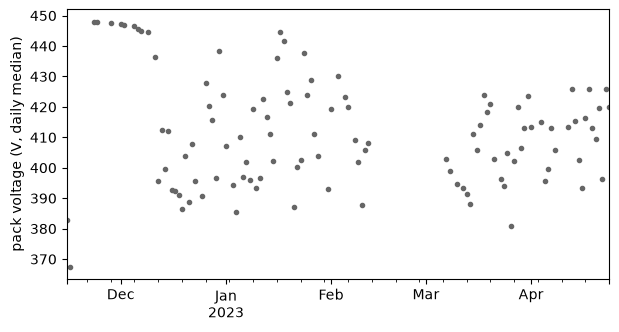

In [4]:
series = frame.dropna(subset=['time']).set_index('time')['value'].sort_index()
ax = series.resample('1D').median().plot(figsize=(7, 3.5), style='.', color='0.4')
ax.set_xlabel('')
ax.set_ylabel('pack voltage (V, daily median)')
plt.show()

Daily median pack voltage of CUP1 from November 2022 to April 2023, from cleaned timestamps, with a gap in early March.